Imports:

In [141]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import seaborn as sns
import re

Data Cleaning:

In [142]:
df = pd.read_csv("animal-data-1.csv")
df

,id,intakedate,intakereason,istransfer,sheltercode,identichipnumber,animalname,breedname,basecolour,speciesname,...,movementdate,movementtype,istrial,returndate,returnedreason,deceaseddate,deceasedreason,diedoffshelter,puttosleep,isdoa
0,15801,2009-11-28 00:00:00,Moving,0,C09115463,0A115D7358,Jadzia,Domestic Short Hair,Tortie,Cat,...,2017-05-13 00:00:00,Adoption,0.0,NaN,Stray,NaN,Died in care,0,0,0
1,15932,2009-12-08 00:00:00,Moving,0,D09125594,0A11675477,Gonzo,German Shepherd Dog/Mix,Tan,Dog,...,2017-04-24 00:00:00,Adoption,0.0,NaN,Stray,NaN,Died in care,0,0,0
2,28859,2012-08-10 00:00:00,Abandoned,0,D12082309,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Various,Dog,...,2017-04-15 00:00:00,Adoption,0.0,NaN,Stray,NaN,Died in care,0,0,0
3,30812,2013-01-11 00:00:00,Abandoned,0,C1301091,0A13403D4D,Pretty Girl,Domestic Short Hair,Dilute tortoiseshell,Cat,...,2017-04-18 00:00:00,Foster,0.0,2018-05-29 00:00:00,Stray,NaN,Died in care,0,0,0
4,30812,2013-01-11 00:00:00,Abandoned,0,C1301091,0A13403D4D,Pretty Girl,Domestic Short Hair,Dilute tortoiseshell,Cat,...,2018-05-29 00:00:00,Adoption,0.0,NaN,Stray,NaN,Died in care,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10285,64584,2019-08-27 16:52:09,Litter relinquishment,0,C19081429,981020029330984,Max,Domestic Medium Hair,Orange and White,Cat,...,2019-08-29 00:00:00,Adoption,0.0,NaN,Stray,NaN,Court Order/ Legal,0,0,0
10286,64588,2019-08-27 18:14:11,Stray,0,C19081418,981020033133599,Punkin,Domestic Short Hair,Calico,Cat,...,2019-08-28 00:00:00,Foster,0.0,NaN,Stray,NaN,Court Order/ Legal,0,0,0
10287,64606,2019-08-29 12:10:21,Stray,0,D19081440,0A1243400C,Dozer,Coonhound,Red,Dog,...,2019-08-29 00:00:00,Reclaimed,0.0,NaN,Stray,NaN,Court Order/ Legal,0,0,0
10288,64608,2019-08-29 18:58:06,Stray,0,D19081421,982000363034690,Lucy Farmer,Beagle,Tricolour,Dog,...,2019-08-30 00:00:00,Reclaimed,0.0,NaN,Stray,NaN,Court Order/ Legal,0,0,0


In [143]:
df.isna().sum()

id                     0
intakedate             0
intakereason           2
istransfer             0
sheltercode            0
identichipnumber    1966
animalname             0
breedname             45
basecolour             0
speciesname            0
animalage              0
sexname                0
location               0
movementdate           0
movementtype           0
istrial                1
returndate          7034
returnedreason         0
deceaseddate        9964
deceasedreason         0
diedoffshelter         0
puttosleep             0
isdoa                  0
dtype: int64

In [144]:
df['intakedate'] = pd.to_datetime(df['intakedate'])
df['intake_date'] = df['intakedate'].dt.date
df['intake_time'] = df['intakedate'].dt.time
df['movementdate'] = pd.to_datetime(df['movementdate'])
df['movement_date'] = df['movementdate'].dt.date
df['movement_time'] = df['movementdate'].dt.time

df['returndate'] = pd.to_datetime(df['returndate'])
df['return_date'] = df['returndate'].dt.date
df['return_time'] = df['returndate'].dt.time

df['deceaseddate'] = pd.to_datetime(df['deceaseddate'])
df['death_date'] = df['deceaseddate'].dt.date
df['death_time'] = df['deceaseddate'].dt.time

In [145]:
df = df.drop(['intakedate', 'movementdate', 'returndate', 'deceaseddate'], axis = 1)

In [146]:
df['intakereason'] = df['intakereason'].fillna('Unknown')

In [147]:
def convert_to_months(age):
    # Extract years, months, and weeks using regex
    years_match = re.search(r'(\d+)\s*years?', age)
    months_match = re.search(r'(\d+)\s*months?', age)
    weeks_match = re.search(r'(\d+)\s*weeks?', age)
    
    # Convert to integers, default to 0 if not present
    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0
    weeks = int(weeks_match.group(1)) if weeks_match else 0
    
    # Convert weeks to months (approximation: 1 week = 0.23 months)
    weeks_in_months = weeks * 0.23
    
    # Total months
    return round(years * 12 + months + weeks_in_months, 2)

# Apply the function to the Age column
df['age_in_months'] = df['animalage'].apply(convert_to_months)
df

,id,intakereason,istransfer,sheltercode,identichipnumber,animalname,breedname,basecolour,speciesname,animalage,...,isdoa,intake_date,intake_time,movement_date,movement_time,return_date,return_time,death_date,death_time,age_in_months
0,15801,Moving,0,C09115463,0A115D7358,Jadzia,Domestic Short Hair,Tortie,Cat,9 years 2 months.,...,0,2009-11-28,00:00:00,2017-05-13,00:00:00,NaT,NaT,NaT,NaT,110.00
1,15932,Moving,0,D09125594,0A11675477,Gonzo,German Shepherd Dog/Mix,Tan,Dog,9 years 1 month.,...,0,2009-12-08,00:00:00,2017-04-24,00:00:00,NaT,NaT,NaT,NaT,109.00
2,28859,Abandoned,0,D12082309,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Various,Dog,6 years 8 months.,...,0,2012-08-10,00:00:00,2017-04-15,00:00:00,NaT,NaT,NaT,NaT,80.00
3,30812,Abandoned,0,C1301091,0A13403D4D,Pretty Girl,Domestic Short Hair,Dilute tortoiseshell,Cat,8 years 11 months.,...,0,2013-01-11,00:00:00,2017-04-18,00:00:00,2018-05-29,00:00:00,NaT,NaT,107.00
4,30812,Abandoned,0,C1301091,0A13403D4D,Pretty Girl,Domestic Short Hair,Dilute tortoiseshell,Cat,8 years 11 months.,...,0,2013-01-11,00:00:00,2018-05-29,00:00:00,NaT,NaT,NaT,NaT,107.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10285,64584,Litter relinquishment,0,C19081429,981020029330984,Max,Domestic Medium Hair,Orange and White,Cat,21 weeks.,...,0,2019-08-27,16:52:09,2019-08-29,00:00:00,NaT,NaT,NaT,NaT,4.83
10286,64588,Stray,0,C19081418,981020033133599,Punkin,Domestic Short Hair,Calico,Cat,6 weeks.,...,0,2019-08-27,18:14:11,2019-08-28,00:00:00,NaT,NaT,NaT,NaT,1.38
10287,64606,Stray,0,D19081440,0A1243400C,Dozer,Coonhound,Red,Dog,6 years 8 months.,...,0,2019-08-29,12:10:21,2019-08-29,00:00:00,NaT,NaT,NaT,NaT,80.00
10288,64608,Stray,0,D19081421,982000363034690,Lucy Farmer,Beagle,Tricolour,Dog,7 years 5 months.,...,0,2019-08-29,18:58:06,2019-08-30,00:00:00,NaT,NaT,NaT,NaT,89.00


In [148]:
df.isna().sum()

id                     0
intakereason           0
istransfer             0
sheltercode            0
identichipnumber    1966
animalname             0
breedname             45
basecolour             0
speciesname            0
animalage              0
sexname                0
location               0
movementtype           0
istrial                1
returnedreason         0
deceasedreason         0
diedoffshelter         0
puttosleep             0
isdoa                  0
intake_date            0
intake_time            0
movement_date          0
movement_time          0
return_date         7034
return_time         7034
death_date          9964
death_time          9964
age_in_months          0
dtype: int64

In [149]:
df

,id,intakereason,istransfer,sheltercode,identichipnumber,animalname,breedname,basecolour,speciesname,animalage,...,isdoa,intake_date,intake_time,movement_date,movement_time,return_date,return_time,death_date,death_time,age_in_months
0,15801,Moving,0,C09115463,0A115D7358,Jadzia,Domestic Short Hair,Tortie,Cat,9 years 2 months.,...,0,2009-11-28,00:00:00,2017-05-13,00:00:00,NaT,NaT,NaT,NaT,110.00
1,15932,Moving,0,D09125594,0A11675477,Gonzo,German Shepherd Dog/Mix,Tan,Dog,9 years 1 month.,...,0,2009-12-08,00:00:00,2017-04-24,00:00:00,NaT,NaT,NaT,NaT,109.00
2,28859,Abandoned,0,D12082309,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Various,Dog,6 years 8 months.,...,0,2012-08-10,00:00:00,2017-04-15,00:00:00,NaT,NaT,NaT,NaT,80.00
3,30812,Abandoned,0,C1301091,0A13403D4D,Pretty Girl,Domestic Short Hair,Dilute tortoiseshell,Cat,8 years 11 months.,...,0,2013-01-11,00:00:00,2017-04-18,00:00:00,2018-05-29,00:00:00,NaT,NaT,107.00
4,30812,Abandoned,0,C1301091,0A13403D4D,Pretty Girl,Domestic Short Hair,Dilute tortoiseshell,Cat,8 years 11 months.,...,0,2013-01-11,00:00:00,2018-05-29,00:00:00,NaT,NaT,NaT,NaT,107.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10285,64584,Litter relinquishment,0,C19081429,981020029330984,Max,Domestic Medium Hair,Orange and White,Cat,21 weeks.,...,0,2019-08-27,16:52:09,2019-08-29,00:00:00,NaT,NaT,NaT,NaT,4.83
10286,64588,Stray,0,C19081418,981020033133599,Punkin,Domestic Short Hair,Calico,Cat,6 weeks.,...,0,2019-08-27,18:14:11,2019-08-28,00:00:00,NaT,NaT,NaT,NaT,1.38
10287,64606,Stray,0,D19081440,0A1243400C,Dozer,Coonhound,Red,Dog,6 years 8 months.,...,0,2019-08-29,12:10:21,2019-08-29,00:00:00,NaT,NaT,NaT,NaT,80.00
10288,64608,Stray,0,D19081421,982000363034690,Lucy Farmer,Beagle,Tricolour,Dog,7 years 5 months.,...,0,2019-08-29,18:58:06,2019-08-30,00:00:00,NaT,NaT,NaT,NaT,89.00


In [150]:
df = df.drop(['istrial', 'animalname', 'basecolour', 'identichipnumber','sheltercode'], axis = 1)
df

,id,intakereason,istransfer,breedname,speciesname,animalage,sexname,location,movementtype,returnedreason,...,isdoa,intake_date,intake_time,movement_date,movement_time,return_date,return_time,death_date,death_time,age_in_months
0,15801,Moving,0,Domestic Short Hair,Cat,9 years 2 months.,Female,Adoptable Cat Glass Colony,Adoption,Stray,...,0,2009-11-28,00:00:00,2017-05-13,00:00:00,NaT,NaT,NaT,NaT,110.00
1,15932,Moving,0,German Shepherd Dog/Mix,Dog,9 years 1 month.,Male,Adoptable Dogs,Adoption,Stray,...,0,2009-12-08,00:00:00,2017-04-24,00:00:00,NaT,NaT,NaT,NaT,109.00
2,28859,Abandoned,0,Shep Mix/Siberian Husky,Dog,6 years 8 months.,Female,Adoptable Dogs,Adoption,Stray,...,0,2012-08-10,00:00:00,2017-04-15,00:00:00,NaT,NaT,NaT,NaT,80.00
3,30812,Abandoned,0,Domestic Short Hair,Cat,8 years 11 months.,Female,Stray Cats,Foster,Stray,...,0,2013-01-11,00:00:00,2017-04-18,00:00:00,2018-05-29,00:00:00,NaT,NaT,107.00
4,30812,Abandoned,0,Domestic Short Hair,Cat,8 years 11 months.,Female,Stray Cats,Adoption,Stray,...,0,2013-01-11,00:00:00,2018-05-29,00:00:00,NaT,NaT,NaT,NaT,107.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10285,64584,Litter relinquishment,0,Domestic Medium Hair,Cat,21 weeks.,Male,Cat room C,Adoption,Stray,...,0,2019-08-27,16:52:09,2019-08-29,00:00:00,NaT,NaT,NaT,NaT,4.83
10286,64588,Stray,0,Domestic Short Hair,Cat,6 weeks.,Female,Cat room C,Foster,Stray,...,0,2019-08-27,18:14:11,2019-08-28,00:00:00,NaT,NaT,NaT,NaT,1.38
10287,64606,Stray,0,Coonhound,Dog,6 years 8 months.,Male,Dog room B,Reclaimed,Stray,...,0,2019-08-29,12:10:21,2019-08-29,00:00:00,NaT,NaT,NaT,NaT,80.00
10288,64608,Stray,0,Beagle,Dog,7 years 5 months.,Female,Canine intake room,Reclaimed,Stray,...,0,2019-08-29,18:58:06,2019-08-30,00:00:00,NaT,NaT,NaT,NaT,89.00


In [151]:
df.columns

Index(['id', 'intakereason', 'istransfer', 'breedname', 'speciesname',
       'animalage', 'sexname', 'location', 'movementtype', 'returnedreason',
       'deceasedreason', 'diedoffshelter', 'puttosleep', 'isdoa',
       'intake_date', 'intake_time', 'movement_date', 'movement_time',
       'return_date', 'return_time', 'death_date', 'death_time',
       'age_in_months'],
      dtype='object')

Data Exploration:

In [152]:
shelters = df.groupby("deceasedreason").agg("count").reset_index()
shelters = shelters[['deceasedreason', 'id']]
shelters = shelters.sort_values(by = 'id', ascending = False).reset_index()
shelters = shelters.tail(10)
shelters

,index,deceasedreason,id
3,0,Biting,20
4,6,Medical,16
5,2,Dead On Arrival,15
6,10,Temperament/Behavior,12
7,7,Owner Requested,11
8,12,Vet advised euthanasia,9
9,9,TM - Treatable Manageable,8
10,4,Died in community,7
11,8,Sick/Injured,6
12,5,Healthy,1


C:\Users\Trish\AppData\Local\Temp\ipykernel_37516\2969267961.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20b')
C:\Users\Trish\AppData\Local\Temp\ipykernel_37516\2969267961.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(shelters['deceasedreason'], rotation='vertical')


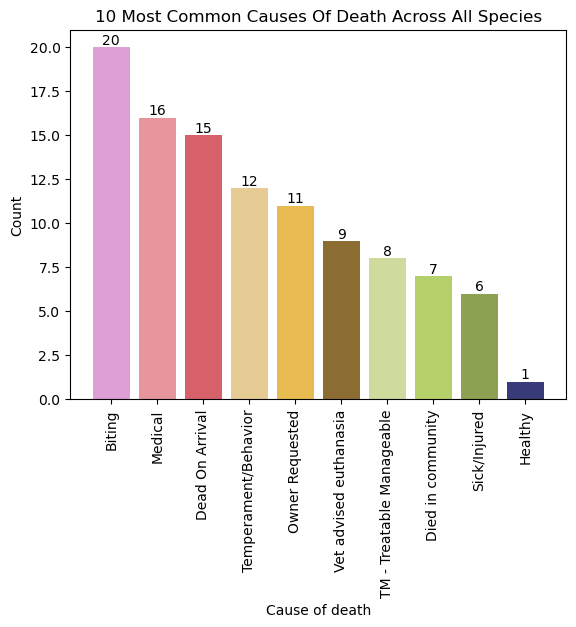

In [153]:
cmap = plt.cm.get_cmap('tab20b')
norm = plt.Normalize(min(shelters['id']), max(shelters['id']))
fig, ax = plt.subplots()
bars = ax.bar(shelters['deceasedreason'], shelters['id'], color = cmap(norm(shelters['id'])))
ax.set_xticklabels(shelters['deceasedreason'], rotation='vertical')
ax.set_title("10 Most Common Causes Of Death Across All Species")
ax.set_ylabel("Count")
ax.set_xlabel("Cause of death")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, 
            str(height), ha='center', va='bottom')

In [154]:
fig.savefig("death_count.jpg")

In [155]:
df.to_csv("cleaned.csv")

C:\Users\Trish\AppData\Local\Temp\ipykernel_37516\922370312.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\Trish\AppData\Local\Temp\ipykernel_37516\922370312.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(animals['location'], rotation='vertical')


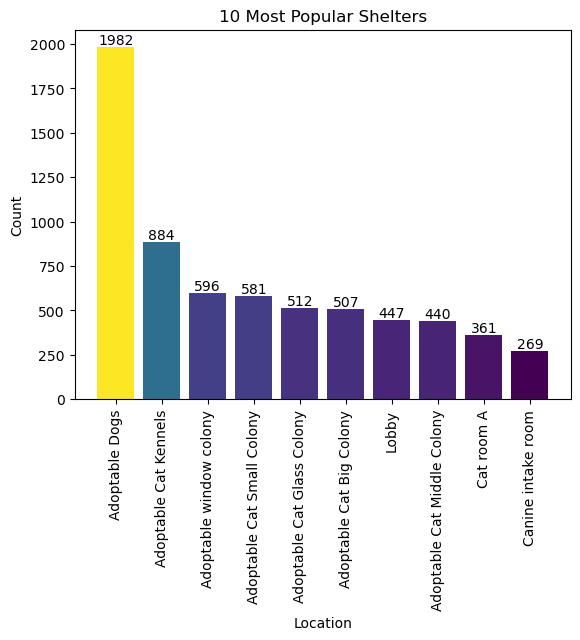

In [156]:
animals = df.groupby(['speciesname', 'location']).agg("count").reset_index()
animals = animals[['speciesname', 'location', 'id']]
animals = animals.sort_values(by = "id",ascending=False)
animals = animals.head(10)


cmap = plt.cm.get_cmap('viridis')
norm = plt.Normalize(min(animals['id']), max(animals['id']))
fig1, ax = plt.subplots()
bars = ax.bar(animals['location'], animals['id'], color = cmap(norm(animals['id'])))
ax.set_xticklabels(animals['location'], rotation='vertical')
ax.set_title("10 Most Popular Shelters")
ax.set_ylabel("Count")
ax.set_xlabel("Location")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, 
            str(height), ha='center', va='bottom')

In [157]:
fig1.savefig("Popular Shelters.jpg")

[Text(0.5, 80.7222222222222, 'Reason for Return'),
 Text(158.22222222222223, 0.5, 'Animal'),
 Text(0.5, 1.0, 'Reasons for return per Animal')]

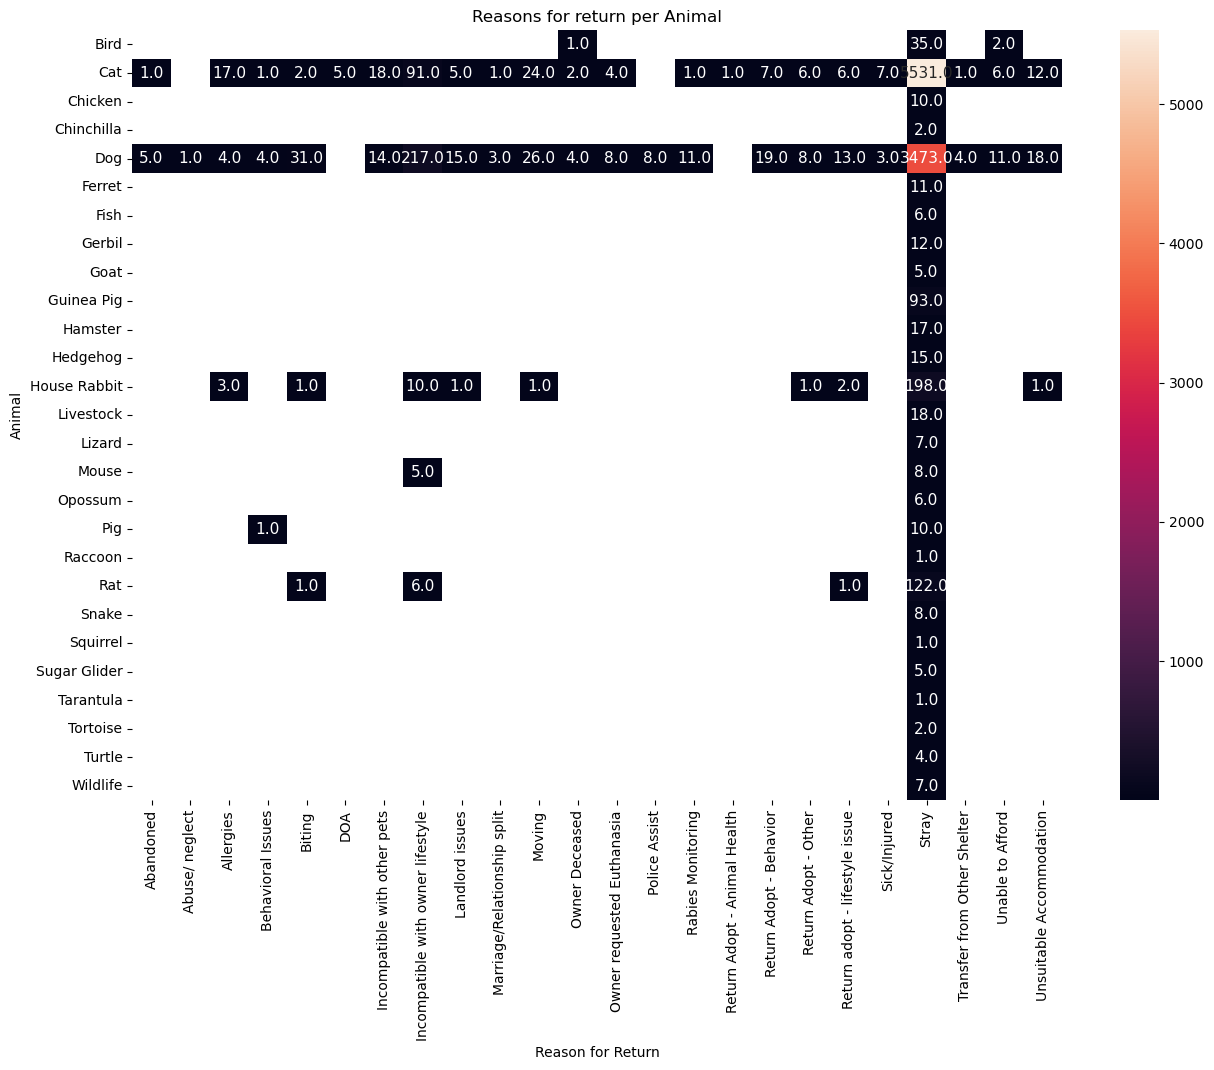

In [158]:
returns = df.groupby(['speciesname', 'returnedreason']).agg("count").reset_index()
returns = returns[['speciesname', 'returnedreason', 'id']]
returns = returns.sort_values(by = "id",ascending=False)
returns = returns.head(5)
ct = pd.crosstab(df['speciesname'], df['returnedreason'], values = df['id'], aggfunc = "count", dropna = True)
ct
plt.figure(figsize=(15, 10))
a = sns.heatmap(ct, annot = True, fmt = '.1f', annot_kws={"size": 11})
a.set(xlabel ="Reason for Return", ylabel = "Animal", title ='Reasons for return per Animal')

In [159]:
plt.savefig("ReturnReason.png")

<Figure size 640x480 with 0 Axes>

In [160]:
deceased_animals = df[df['death_date'].notna()]
deceased_animals

,id,intakereason,istransfer,breedname,speciesname,animalage,sexname,location,movementtype,returnedreason,...,isdoa,intake_date,intake_time,movement_date,movement_time,return_date,return_time,death_date,death_time,age_in_months
12,46437,Abandoned,0,Domestic Long Hair,Cat,12 years 3 months.,Female,Stray Cats,Foster,Stray,...,0,2016-10-26,00:00:00,2017-03-25,00:00:00,2017-04-07,00:00:00,2018-02-10,00:00:00,147.00
13,46437,Abandoned,0,Domestic Long Hair,Cat,12 years 3 months.,Female,Stray Cats,Adoption,Incompatible with owner lifestyle,...,0,2016-10-26,00:00:00,2017-04-07,00:00:00,2018-02-09,00:00:00,2018-02-10,00:00:00,147.00
33,47360,Abandoned,0,DSH/Unknown,Cat,16 years 3 months.,Female,Office,Foster,Stray,...,0,2017-02-11,00:00:00,2017-03-07,00:00:00,2017-04-22,00:00:00,2017-06-13,00:00:00,195.00
34,47360,Abandoned,0,DSH/Unknown,Cat,16 years 3 months.,Female,Office,Foster,Stray,...,0,2017-02-11,00:00:00,2017-04-25,00:00:00,2017-06-11,00:00:00,2017-06-13,00:00:00,195.00
35,47360,Abandoned,0,DSH/Unknown,Cat,16 years 3 months.,Female,Office,Foster,Stray,...,0,2017-02-11,00:00:00,2017-06-12,00:00:00,2017-06-13,00:00:00,2017-06-13,00:00:00,195.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9916,64043,Stray,0,Domestic Short Hair,Cat,5 weeks.,Male,Cat room B,Foster,Stray,...,0,2019-07-19,13:57:01,2019-07-26,00:00:00,NaT,NaT,2019-07-28,00:00:00,1.15
10020,64171,Stray,0,Domestic Short Hair,Cat,3 days.,Unknown,Feline intake room,Foster,Stray,...,0,2019-07-30,08:13:34,2019-07-31,00:00:00,NaT,NaT,2019-08-01,00:00:00,0.00
10110,64278,Abandoned,0,Domestic Short Hair,Cat,2 weeks.,Unknown,Feline intake room,Foster,Stray,...,1,2019-08-03,15:26:00,2019-08-04,00:00:00,NaT,NaT,2019-08-12,00:00:00,0.46
10162,64330,Incompatible with owner lifestyle,0,Domestic Short Hair,Cat,3 years 0 months.,Male,Adoptable Cat Small Colony,Adoption,Stray,...,0,2019-08-09,12:07:48,2019-08-12,00:00:00,NaT,NaT,2019-08-13,00:00:00,36.00


In [161]:
deathreason = deceased_animals.groupby(['breedname', 'deceasedreason']).size()
total_count = df.groupby('breedname').size()
death_rate = deathreason / total_count
death_rate= death_rate.reset_index(name='death_rate')

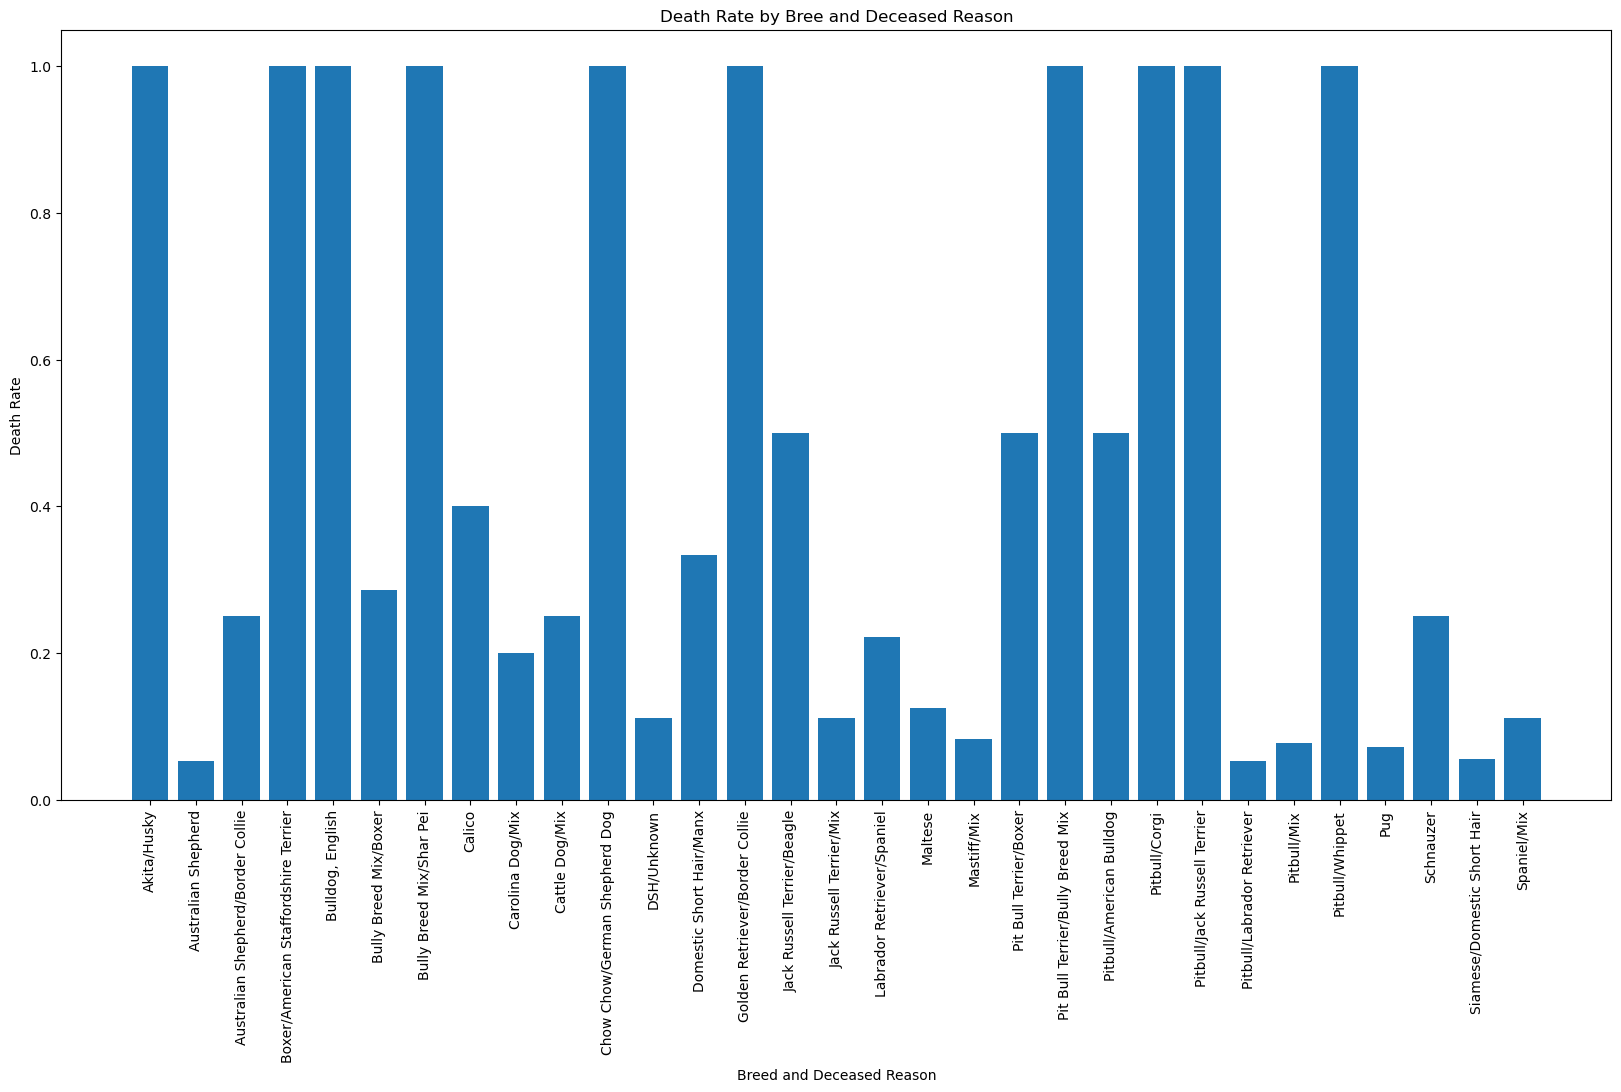

In [162]:
top_death_rate = death_rate[death_rate['death_rate'] > 0.05]

plt.figure(figsize=(20, 10))

plt.bar(top_death_rate['breedname'], top_death_rate['death_rate'])

plt.xlabel('Breed and Deceased Reason')
plt.ylabel('Death Rate')
plt.title('Death Rate by Bree and Deceased Reason')
plt.xticks(rotation=90)  


plt.show()

Text(0.5, 1.0, 'Top 5 Intake Reasons for Dogs Who Died in Care')

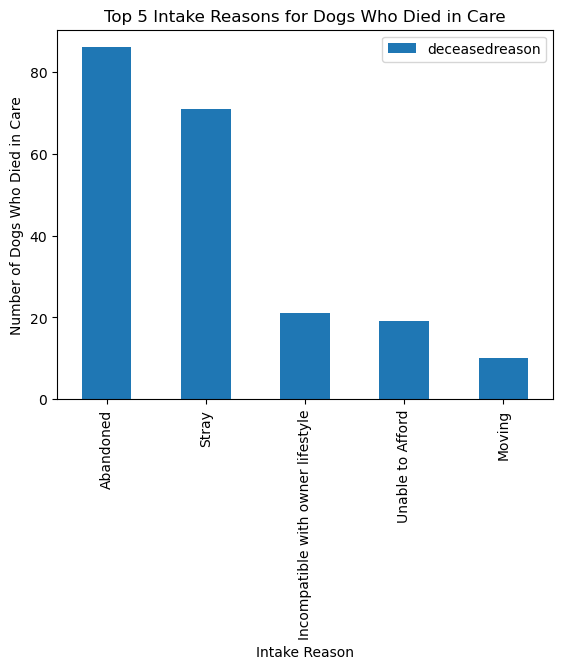

In [163]:
d = df[(df["speciesname"] == "Dog")]
d = d[d["deceasedreason"] == "Died in care"]
d = d.groupby("intakereason").count().reset_index()
d = d.nlargest(5, "deceasedreason")

d.plot(x = "intakereason", y = "deceasedreason", kind = "bar")
plt.xlabel('Intake Reason')
plt.ylabel('Number of Dogs Who Died in Care')
plt.title('Top 5 Intake Reasons for Dogs Who Died in Care')

In [166]:
d1 = df[['sexname','animalage','intake_date','intakereason', 'movementtype', 'movement_date']]
d1

,sexname,animalage,intake_date,intakereason,movementtype,movement_date
0,Female,9 years 2 months.,2009-11-28,Moving,Adoption,2017-05-13
1,Male,9 years 1 month.,2009-12-08,Moving,Adoption,2017-04-24
2,Female,6 years 8 months.,2012-08-10,Abandoned,Adoption,2017-04-15
3,Female,8 years 11 months.,2013-01-11,Abandoned,Foster,2017-04-18
4,Female,8 years 11 months.,2013-01-11,Abandoned,Adoption,2018-05-29
...,...,...,...,...,...,...
10285,Male,21 weeks.,2019-08-27,Litter relinquishment,Adoption,2019-08-29
10286,Female,6 weeks.,2019-08-27,Stray,Foster,2019-08-28
10287,Male,6 years 8 months.,2019-08-29,Stray,Reclaimed,2019-08-29
10288,Female,7 years 5 months.,2019-08-29,Stray,Reclaimed,2019-08-30


In [168]:
d1 = pd.DataFrame(d1)
def convert_to_years(age_str):
    if 'week' in age_str:
        return 0  # for under 52 weeks
    else:
        years = int(age_str.split()[0])  # take the first number (years=0)
        return years
d1['age_in_years'] = d1['animalage'].apply(convert_to_years)
d1[['animalage', 'age_in_years']]

bins = [0, 4, 7, float('inf')]
labels = ['Young (0-4)', 'Adult (4-7)', 'Senior (7+)'] 

d1['age_category'] = pd.cut(d1['age_in_years'].astype(int), bins=bins, labels=labels, right=False)
d1[['age_in_years', 'age_category']]

,age_in_years,age_category
0,9,Senior (7+)
1,9,Senior (7+)
2,6,Adult (4-7)
3,8,Senior (7+)
4,8,Senior (7+)
...,...,...
10285,0,Young (0-4)
10286,0,Young (0-4)
10287,6,Adult (4-7)
10288,7,Senior (7+)


In [169]:
d1[['sexname','age_category','intake_date','intakereason', 'movementtype', 'movement_date']]

,sexname,age_category,intake_date,intakereason,movementtype,movement_date
0,Female,Senior (7+),2009-11-28,Moving,Adoption,2017-05-13
1,Male,Senior (7+),2009-12-08,Moving,Adoption,2017-04-24
2,Female,Adult (4-7),2012-08-10,Abandoned,Adoption,2017-04-15
3,Female,Senior (7+),2013-01-11,Abandoned,Foster,2017-04-18
4,Female,Senior (7+),2013-01-11,Abandoned,Adoption,2018-05-29
...,...,...,...,...,...,...
10285,Male,Young (0-4),2019-08-27,Litter relinquishment,Adoption,2019-08-29
10286,Female,Young (0-4),2019-08-27,Stray,Foster,2019-08-28
10287,Male,Adult (4-7),2019-08-29,Stray,Reclaimed,2019-08-29
10288,Female,Senior (7+),2019-08-29,Stray,Reclaimed,2019-08-30


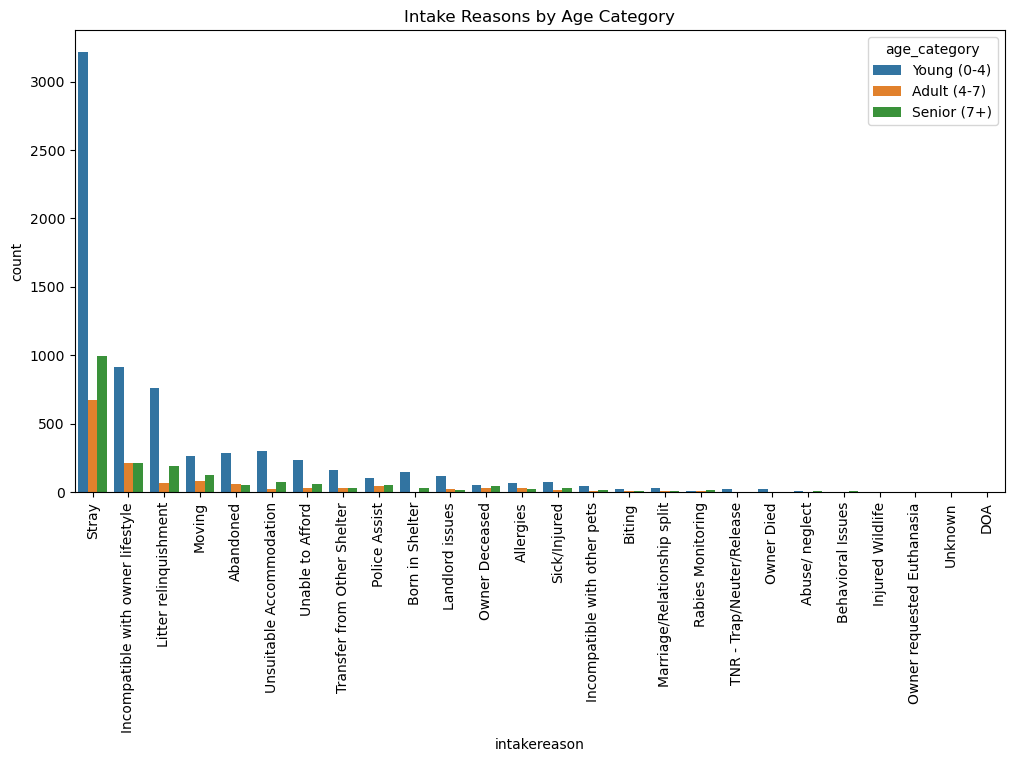

In [170]:
d1['intake_date'] = pd.to_datetime(d1['intake_date'])
d1['movement_date'] = pd.to_datetime(d1['movement_date'])

d1['stay_duration_days'] = (d1['movement_date'] - d1['intake_date']).dt.days #(dt.days takes only days)
grouped = d1.groupby(['sexname', 'age_category'],observed=True)['stay_duration_days'].mean().reset_index()

top_intakereason = d1['intakereason'].value_counts()
top_movementtype = d1['movementtype'].value_counts()
stat_model = d1.groupby(['age_category', 'sexname'],observed=True)['stay_duration_days'].agg(['mean', 'std', 'median', 'min', 'max'])
age_sex_count = d1.groupby(['age_category', 'sexname'],observed=True).size().reset_index(name='count')
d1[['sexname','age_category','stay_duration_days','intakereason', 'movementtype']]

plt.figure(figsize=(12, 6))
sns.countplot(data=d1, x='intakereason', hue='age_category', order=d1['intakereason'].value_counts().index)
plt.title('Intake Reasons by Age Category')
plt.xticks(rotation=90)
plt.show()

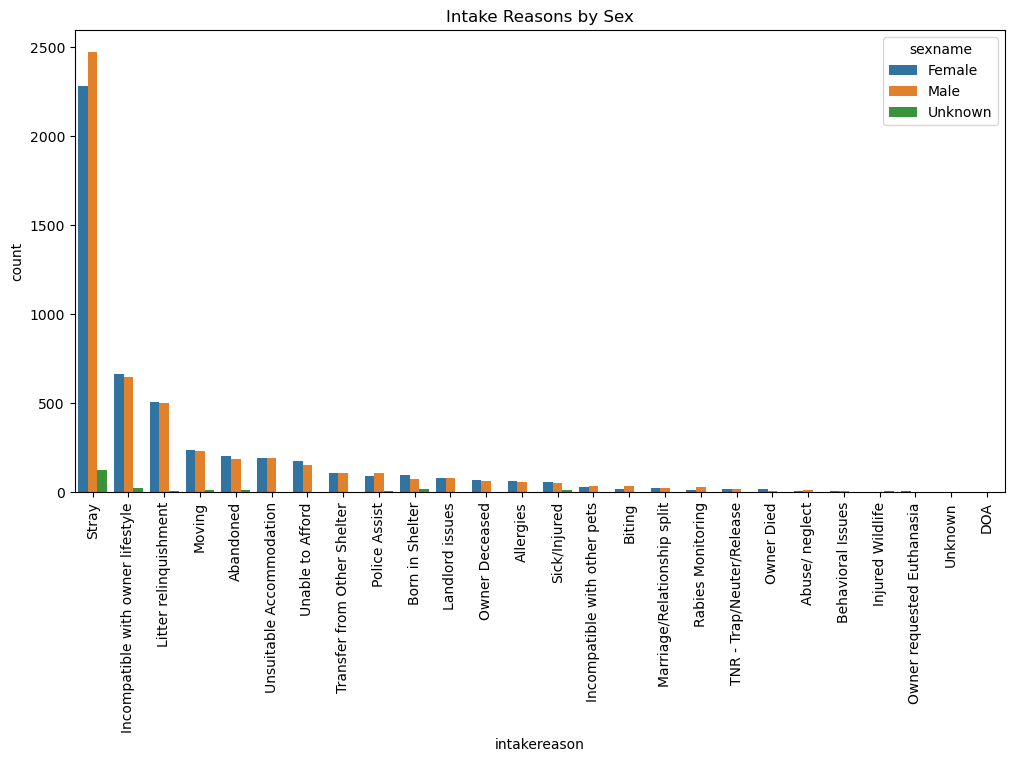

In [171]:
plt.figure(figsize=(12, 6))
sns.countplot(data=d1, x='intakereason', hue='sexname', order=d1['intakereason'].value_counts().index)
plt.title('Intake Reasons by Sex')
plt.xticks(rotation=90)
plt.show()

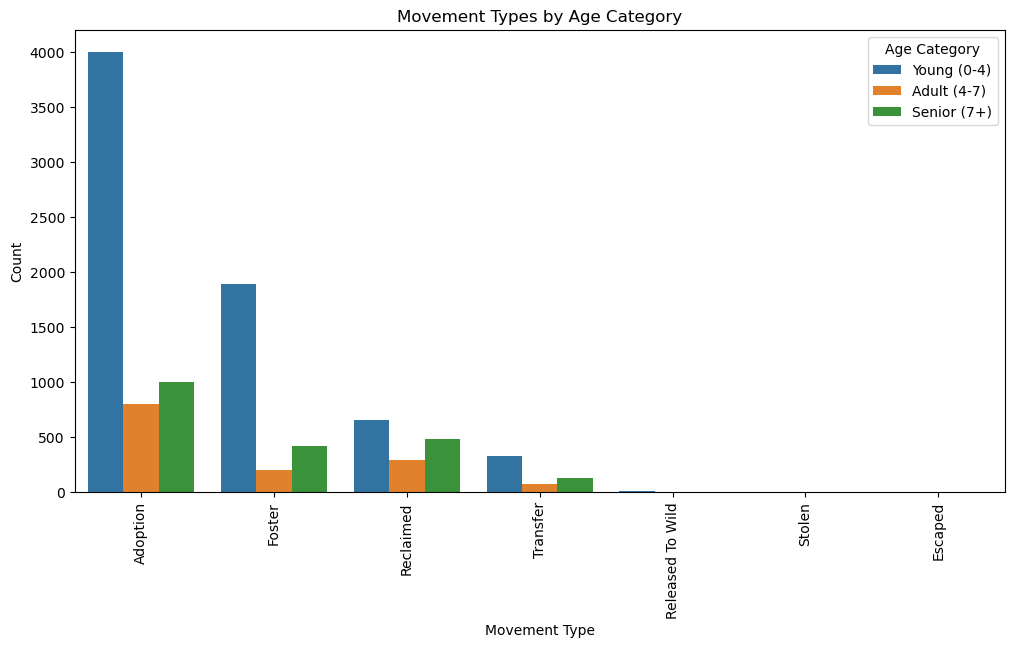

In [172]:
plt.figure(figsize=(12, 6))
sns.countplot(data=d1, x='movementtype', hue='age_category', order=d1['movementtype'].value_counts().index)
plt.title('Movement Types by Age Category')
plt.xlabel('Movement Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Age Category')
plt.show()

C:\Users\Trish\AppData\Local\Temp\ipykernel_37516\3200815837.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  movement_pivot = d1.pivot_table(index='age_category', columns='sexname', values='stay_duration_days', aggfunc='mean')


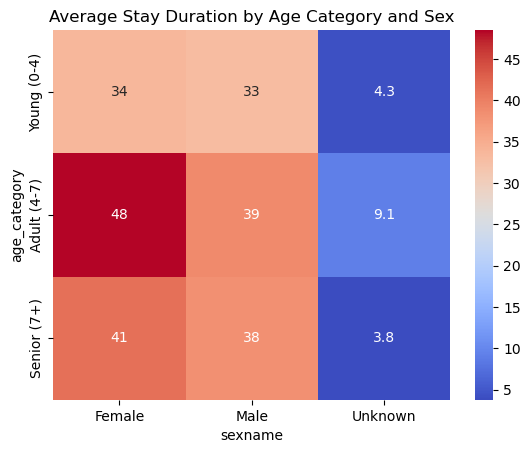

In [174]:
movement_pivot = d1.pivot_table(index='age_category', columns='sexname', values='stay_duration_days', aggfunc='mean')
sns.heatmap(movement_pivot, annot=True, cmap='coolwarm')
plt.title('Average Stay Duration by Age Category and Sex')
plt.show()

In [175]:
df

,id,intakereason,istransfer,breedname,speciesname,animalage,sexname,location,movementtype,returnedreason,...,isdoa,intake_date,intake_time,movement_date,movement_time,return_date,return_time,death_date,death_time,age_in_months
0,15801,Moving,0,Domestic Short Hair,Cat,9 years 2 months.,Female,Adoptable Cat Glass Colony,Adoption,Stray,...,0,2009-11-28,00:00:00,2017-05-13,00:00:00,NaT,NaT,NaT,NaT,110.00
1,15932,Moving,0,German Shepherd Dog/Mix,Dog,9 years 1 month.,Male,Adoptable Dogs,Adoption,Stray,...,0,2009-12-08,00:00:00,2017-04-24,00:00:00,NaT,NaT,NaT,NaT,109.00
2,28859,Abandoned,0,Shep Mix/Siberian Husky,Dog,6 years 8 months.,Female,Adoptable Dogs,Adoption,Stray,...,0,2012-08-10,00:00:00,2017-04-15,00:00:00,NaT,NaT,NaT,NaT,80.00
3,30812,Abandoned,0,Domestic Short Hair,Cat,8 years 11 months.,Female,Stray Cats,Foster,Stray,...,0,2013-01-11,00:00:00,2017-04-18,00:00:00,2018-05-29,00:00:00,NaT,NaT,107.00
4,30812,Abandoned,0,Domestic Short Hair,Cat,8 years 11 months.,Female,Stray Cats,Adoption,Stray,...,0,2013-01-11,00:00:00,2018-05-29,00:00:00,NaT,NaT,NaT,NaT,107.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10285,64584,Litter relinquishment,0,Domestic Medium Hair,Cat,21 weeks.,Male,Cat room C,Adoption,Stray,...,0,2019-08-27,16:52:09,2019-08-29,00:00:00,NaT,NaT,NaT,NaT,4.83
10286,64588,Stray,0,Domestic Short Hair,Cat,6 weeks.,Female,Cat room C,Foster,Stray,...,0,2019-08-27,18:14:11,2019-08-28,00:00:00,NaT,NaT,NaT,NaT,1.38
10287,64606,Stray,0,Coonhound,Dog,6 years 8 months.,Male,Dog room B,Reclaimed,Stray,...,0,2019-08-29,12:10:21,2019-08-29,00:00:00,NaT,NaT,NaT,NaT,80.00
10288,64608,Stray,0,Beagle,Dog,7 years 5 months.,Female,Canine intake room,Reclaimed,Stray,...,0,2019-08-29,18:58:06,2019-08-30,00:00:00,NaT,NaT,NaT,NaT,89.00


In [199]:
t = df[['intake_date', 'speciesname']]
time = t.groupby(["intake_date"]).agg("count").reset_index()
time

,intake_date,speciesname
0,2009-11-28,1
1,2009-12-08,1
2,2012-08-10,1
3,2013-01-11,2
4,2013-03-26,2
...,...,...
880,2019-08-24,5
881,2019-08-26,5
882,2019-08-27,3
883,2019-08-29,2


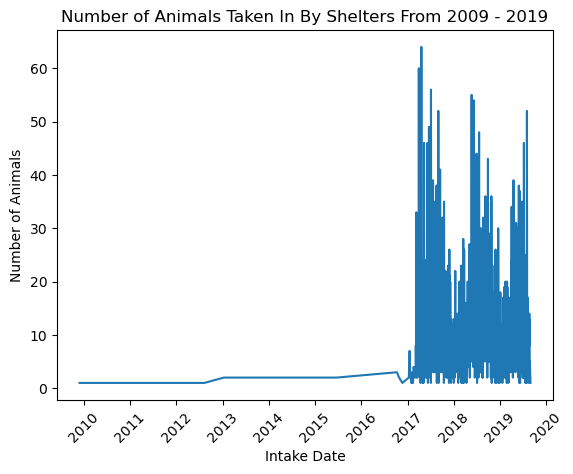

In [203]:
plt.plot(time['intake_date'], time['speciesname'])
plt.xlabel('Intake Date')
plt.ylabel('Number of Animals')
plt.xticks(rotation = 45)
plt.title('Number of Animals Taken In By Shelters From 2009 - 2019')
plt.show()

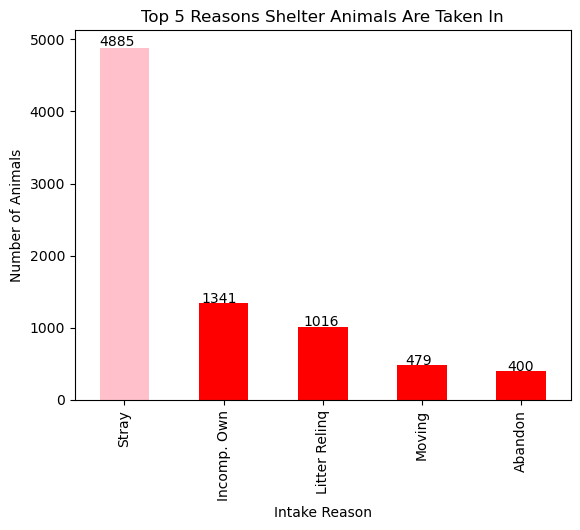

In [205]:
df_1 = df.groupby("intakereason").count().reset_index()
df_1["intakereason"] = df_1["intakereason"].replace({"Stray": "Stray", "Incompatible with owner lifestyle": "Incomp. Own", "Litter relinquishment":"Litter Relinq", "Moving":"Moving", "Abandoned": "Abandon",})
df_1 = df_1.nlargest(5, "deceasedreason")
df_1

ax = df_1.plot(x = "intakereason", y = "id", kind = "bar", legend = False, color = ["pink", "red", "red", "red", "red"])
plt.xlabel('Intake Reason')
plt.ylabel('Number of Animals')
plt.title('Top 5 Reasons Shelter Animals Are Taken In')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.03, p.get_height() * 1.005))